# ME 566 Homework 2

This report uses representative frames from the captured rotation, scale, and translation image sets in `images/`. Choose **Run All** to reproduce the results.


Shared setup (imports and image paths)


In [1]:
from pathlib import Path
import random
from time import perf_counter

import cv2
import numpy as np

from src.detectors import DoG, Fast, Harris, Octree, ShiTomasi
from src.io.image_reader import ImageReader
from src.matchers import Brief, Orb, SIFT
from src.utils import draw_features, save_image

ROOT = Path.cwd()
if not (ROOT / "images").is_dir():
    ROOT = ROOT / "Homework" / "two"
IMAGE_DIR = ROOT / "images"
OUTPUT_DIR = ROOT / "outputs"


RANDOM_SEED = 566


def representative_frames(folder, rng):
    """Randomly select three available captures from a sequence."""
    frames = sorted(folder.glob("frame_*.jpg"), key=lambda path: int(path.stem.split("_")[-1]))
    if len(frames) < 3:
        raise FileNotFoundError(f"Need at least three images in {folder}; found {len(frames)}.")
    return sorted(rng.sample(frames, 3), key=lambda path: int(path.stem.split("_")[-1]))


rng = random.Random(RANDOM_SEED)
IMAGE_PATHS = {
    "rotation": representative_frames(IMAGE_DIR / "hw2_rot_images", rng),
    "scale": representative_frames(IMAGE_DIR / "hw2_scale_images", rng),
    "translation": representative_frames(IMAGE_DIR / "hw2_translation_images", rng),
}
IMAGES = None


def load_images():
    """Read representative frames from each captured transformation set."""
    global IMAGES
    if IMAGES is None:
        if not IMAGE_DIR.exists():
            raise FileNotFoundError("Create images/ and add your camera images.")
        missing = [path for paths in IMAGE_PATHS.values() for path in paths if not path.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing required image(s): {missing}")
        IMAGES = {
            change: [ImageReader(str(path)).images[0] for path in paths]
            for change, paths in IMAGE_PATHS.items()
        }
        OUTPUT_DIR.mkdir(exist_ok=True)
        print(f"Loaded {sum(map(len, IMAGES.values()))} representative images through ImageReader.")
        for change, paths in IMAGE_PATHS.items():
            print(f"  {change}: {', '.join(path.name for path in paths)}")
    return IMAGES


def labeled_panel(image, label, width=480):
    """Resize an image and add a consistent title bar."""
    scale = width / image.shape[1]
    resized = cv2.resize(image, (width, round(image.shape[0] * scale)), interpolation=cv2.INTER_AREA)
    panel = cv2.copyMakeBorder(resized, 52, 3, 3, 3, cv2.BORDER_CONSTANT, value=(250, 250, 250))
    base_scale = 0.7
    text_width = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, base_scale, 2)[0][0]
    font_scale = base_scale * min(1.0, (width - 22) / max(text_width, 1))
    cv2.putText(panel, label, (14, 35), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (20, 20, 20), 2, cv2.LINE_AA)
    return panel


def image_grid(items, columns=2, panel_width=360):
    """Arrange equally-sized labeled images into a clean grid."""
    panels = [labeled_panel(image, label, panel_width) for label, image in items]
    height = max(panel.shape[0] for panel in panels)
    panels = [cv2.copyMakeBorder(panel, 0, height - panel.shape[0], 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255)) for panel in panels]
    blank = np.full_like(panels[0], 255)
    panels.extend([blank.copy() for _ in range((-len(panels)) % columns)])
    rows = [cv2.hconcat(panels[i:i + columns]) for i in range(0, len(panels), columns)]
    return cv2.vconcat(rows)


def show_output(image, filename):
    output_path = OUTPUT_DIR / filename
    save_image(str(output_path), image)
    print(f"Saved: {output_path.relative_to(ROOT)}")
    try:
        from IPython.display import Image, display
        display(Image(filename=str(output_path)))
    except ImportError:
        pass


def print_table(rows, columns):
    text_rows = [[str(row[column]) for column in columns] for row in rows]
    widths = [max(len(column), *(len(row[i]) for row in text_rows)) for i, column in enumerate(columns)]
    print("  ".join(column.ljust(widths[i]) for i, column in enumerate(columns)))
    print("  ".join("-" * width for width in widths))
    for row in text_rows:
        print("  ".join(value.ljust(widths[i]) for i, value in enumerate(row)))


1: A comparison of DoG, Harris, Shi-Tomasi, and FAST feature detectors addressing

- Repeatability,
- Speed, and
- Number of features detected.

Make sure to see how they behave with changes in scale, translation, and rotation. Use images
that captured by your camera. Do not digitally rotate or scale the images. This leads to artifacts
that make the test results meaningless

In [2]:
# Question 1: use the existing detector classes
DETECTORS = {"DoG": DoG, "Harris": Harris, "Shi-Tomasi": ShiTomasi, "FAST": Fast}
Q1_CACHE = None


def _q1_detect_everything():
    """Run each provided detector once on every image from ImageReader."""
    global Q1_CACHE
    if Q1_CACHE is not None:
        return Q1_CACHE
    Q1_CACHE = []
    for change, images in load_images().items():
        for image_index, image in enumerate(images, start=1):
            for name, detector_class in DETECTORS.items():
                detector = detector_class(image)
                start = perf_counter()
                keypoints = detector.detect_features()
                Q1_CACHE.append({
                    "image": f"{change}_{image_index}", "detector": name, "features": len(keypoints),
                    "time (ms)": round((perf_counter() - start) * 1000, 2),
                    "detector object": detector, "keypoints": keypoints,
                })
    return Q1_CACHE


def check_repeatability():
    """Save feature overlays for every detector/image pair for visual repeatability comparison."""
    results = _q1_detect_everything()
    for change in IMAGE_PATHS:
        items = []
        for result in (item for item in results if item["image"].startswith(change)):
            detector = result["detector object"]
            overlay = draw_features(detector.image, result["keypoints"], color=(0, 255, 0))
            frame = result["image"].rsplit("_", 1)[1]
            items.append((f"Frame {frame} | {result['detector']} | {result['features']} features", overlay))
        show_output(image_grid(items, columns=3, panel_width=480), f"q1_{change}_comparison.jpg")
    print("Compare matching physical features across the saved overlays for your scale, translation, and rotation images.")
    return results


def check_speed():
    rows = [{"image": item["image"], "detector": item["detector"], "time (ms)": item["time (ms)"]}
            for item in _q1_detect_everything()]
    print_table(rows, ("image", "detector", "time (ms)"))
    return rows


def check_number_of_features():
    rows = [{"image": item["image"], "detector": item["detector"], "features": item["features"]}
            for item in _q1_detect_everything()]
    print_table(rows, ("image", "detector", "features"))
    return rows


Loaded 9 representative images through ImageReader.
  rotation: frame_145.jpg, frame_175.jpg, frame_185.jpg
  scale: frame_110.jpg, frame_120.jpg, frame_165.jpg
  translation: frame_130.jpg, frame_160.jpg, frame_170.jpg


Saved: outputs/q1_rotation_comparison.jpg


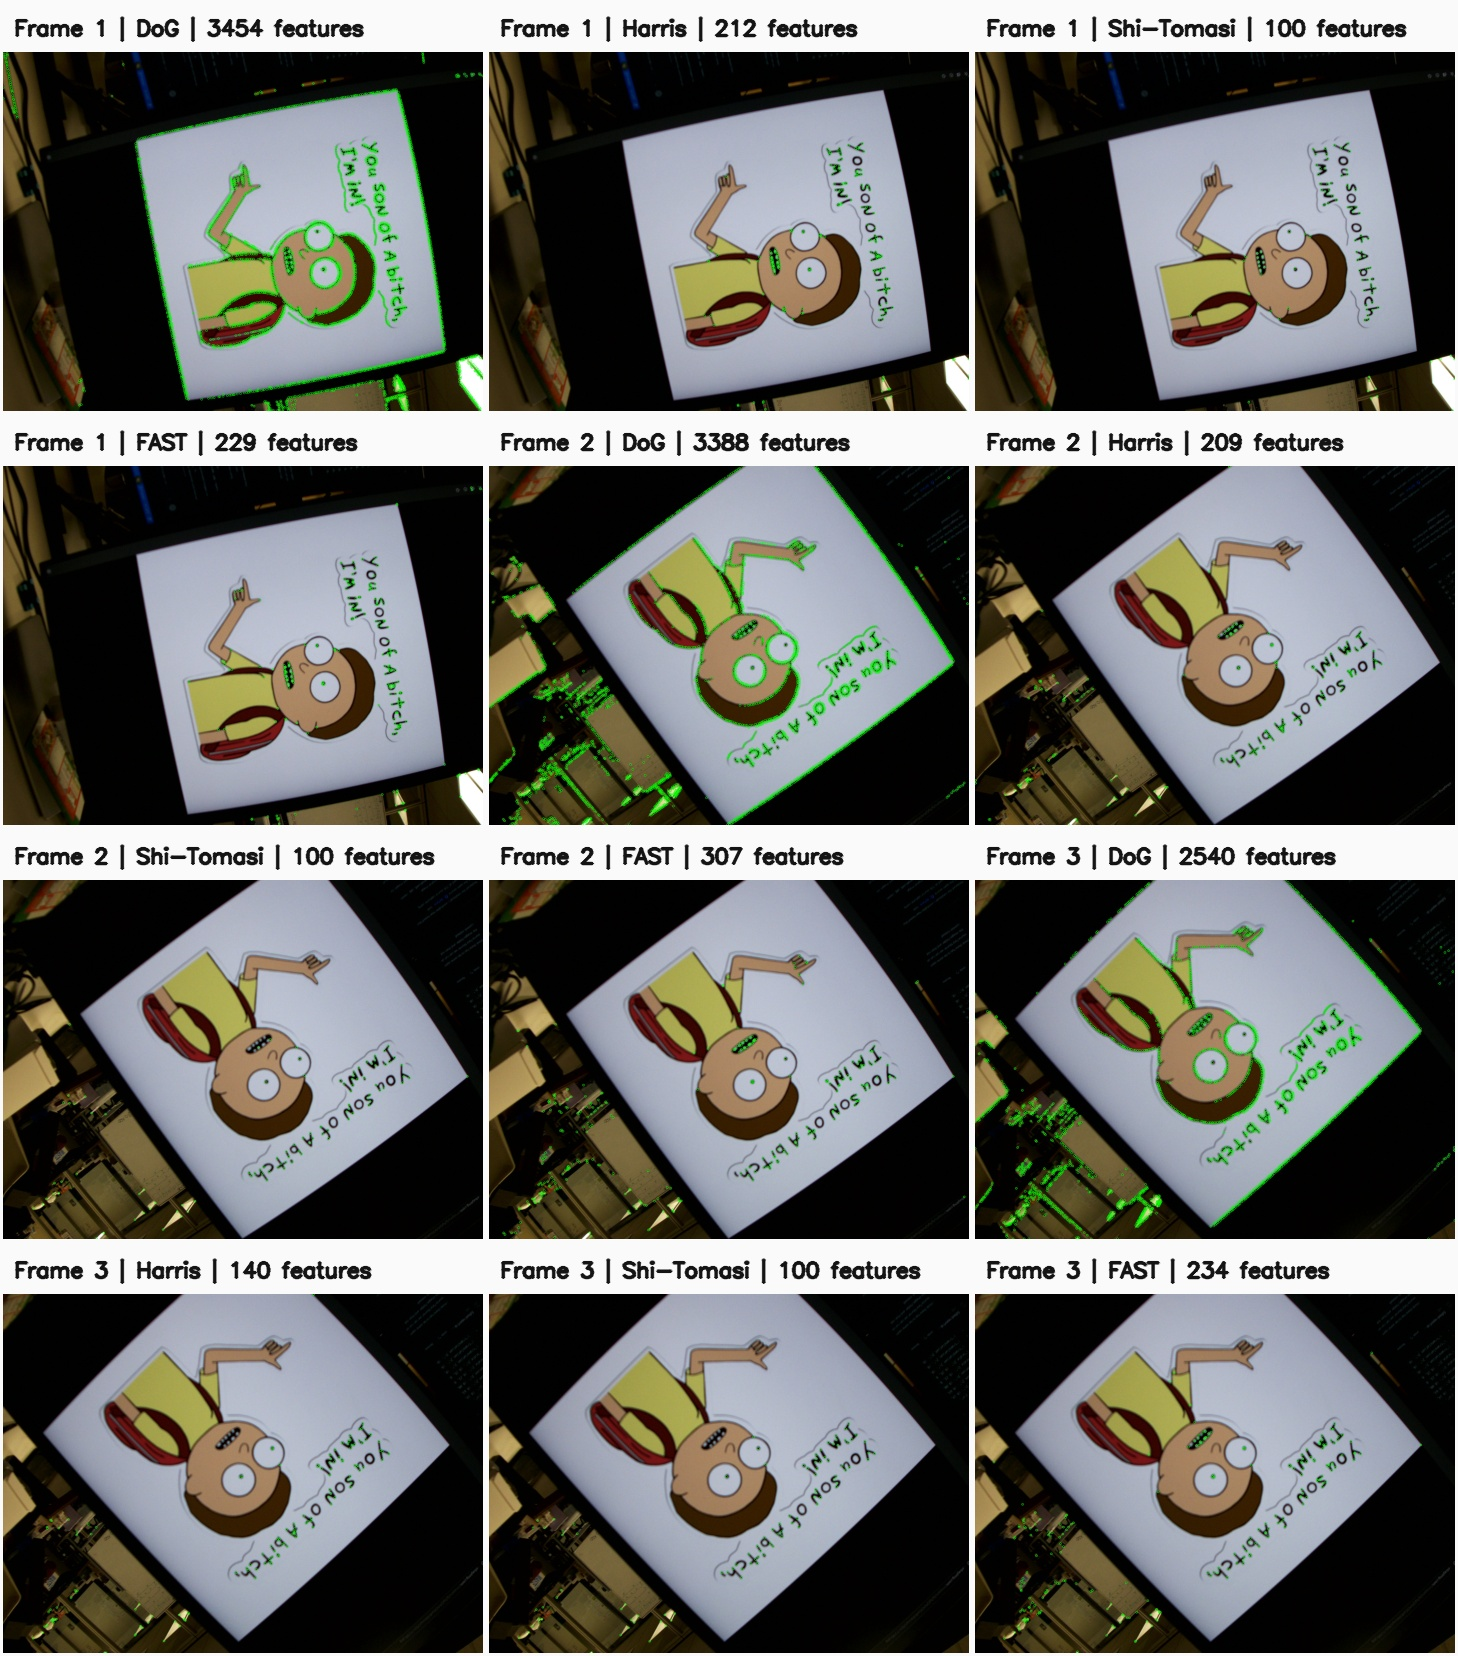

Saved: outputs/q1_scale_comparison.jpg


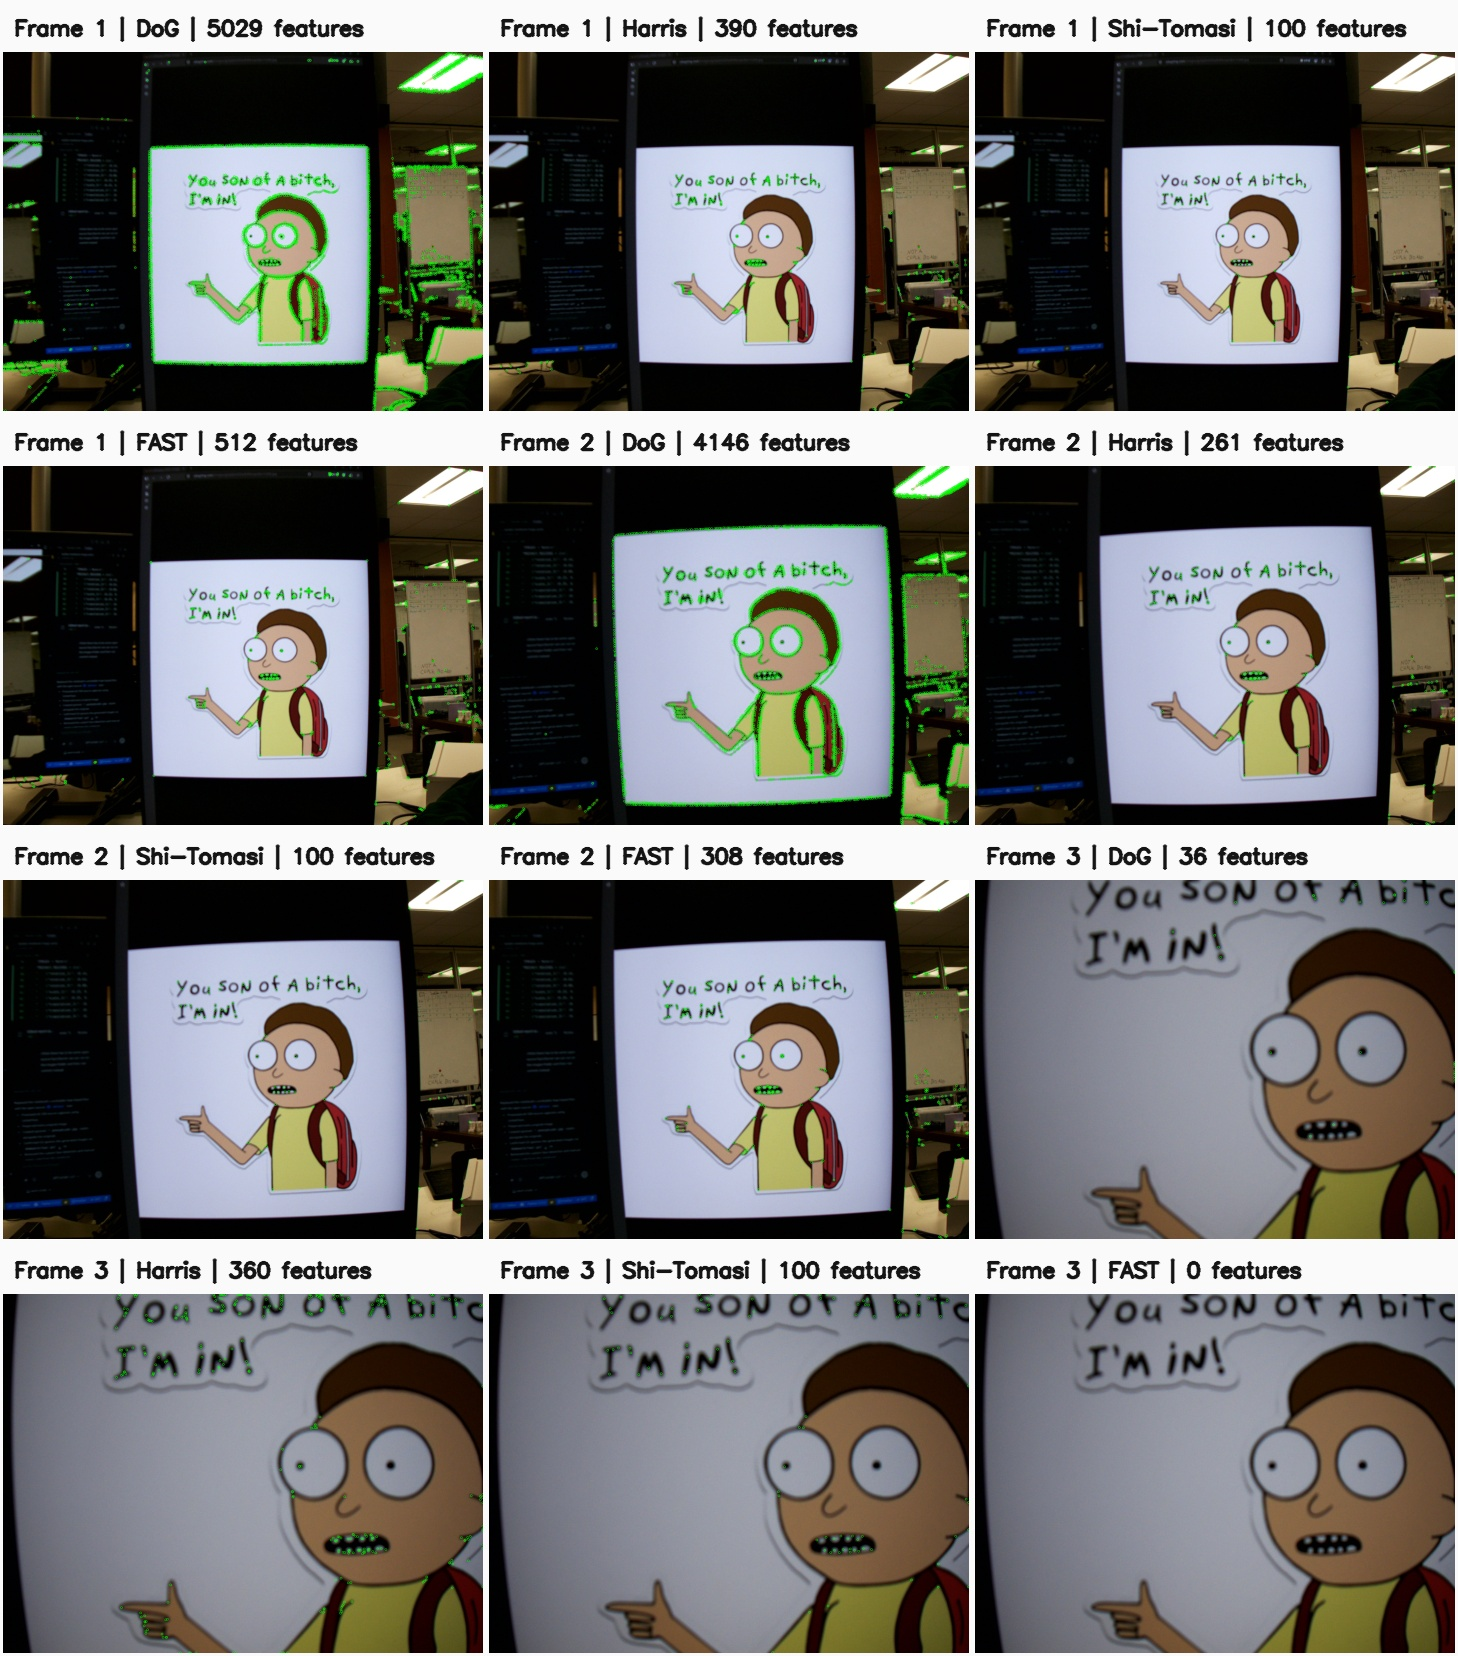

Saved: outputs/q1_translation_comparison.jpg


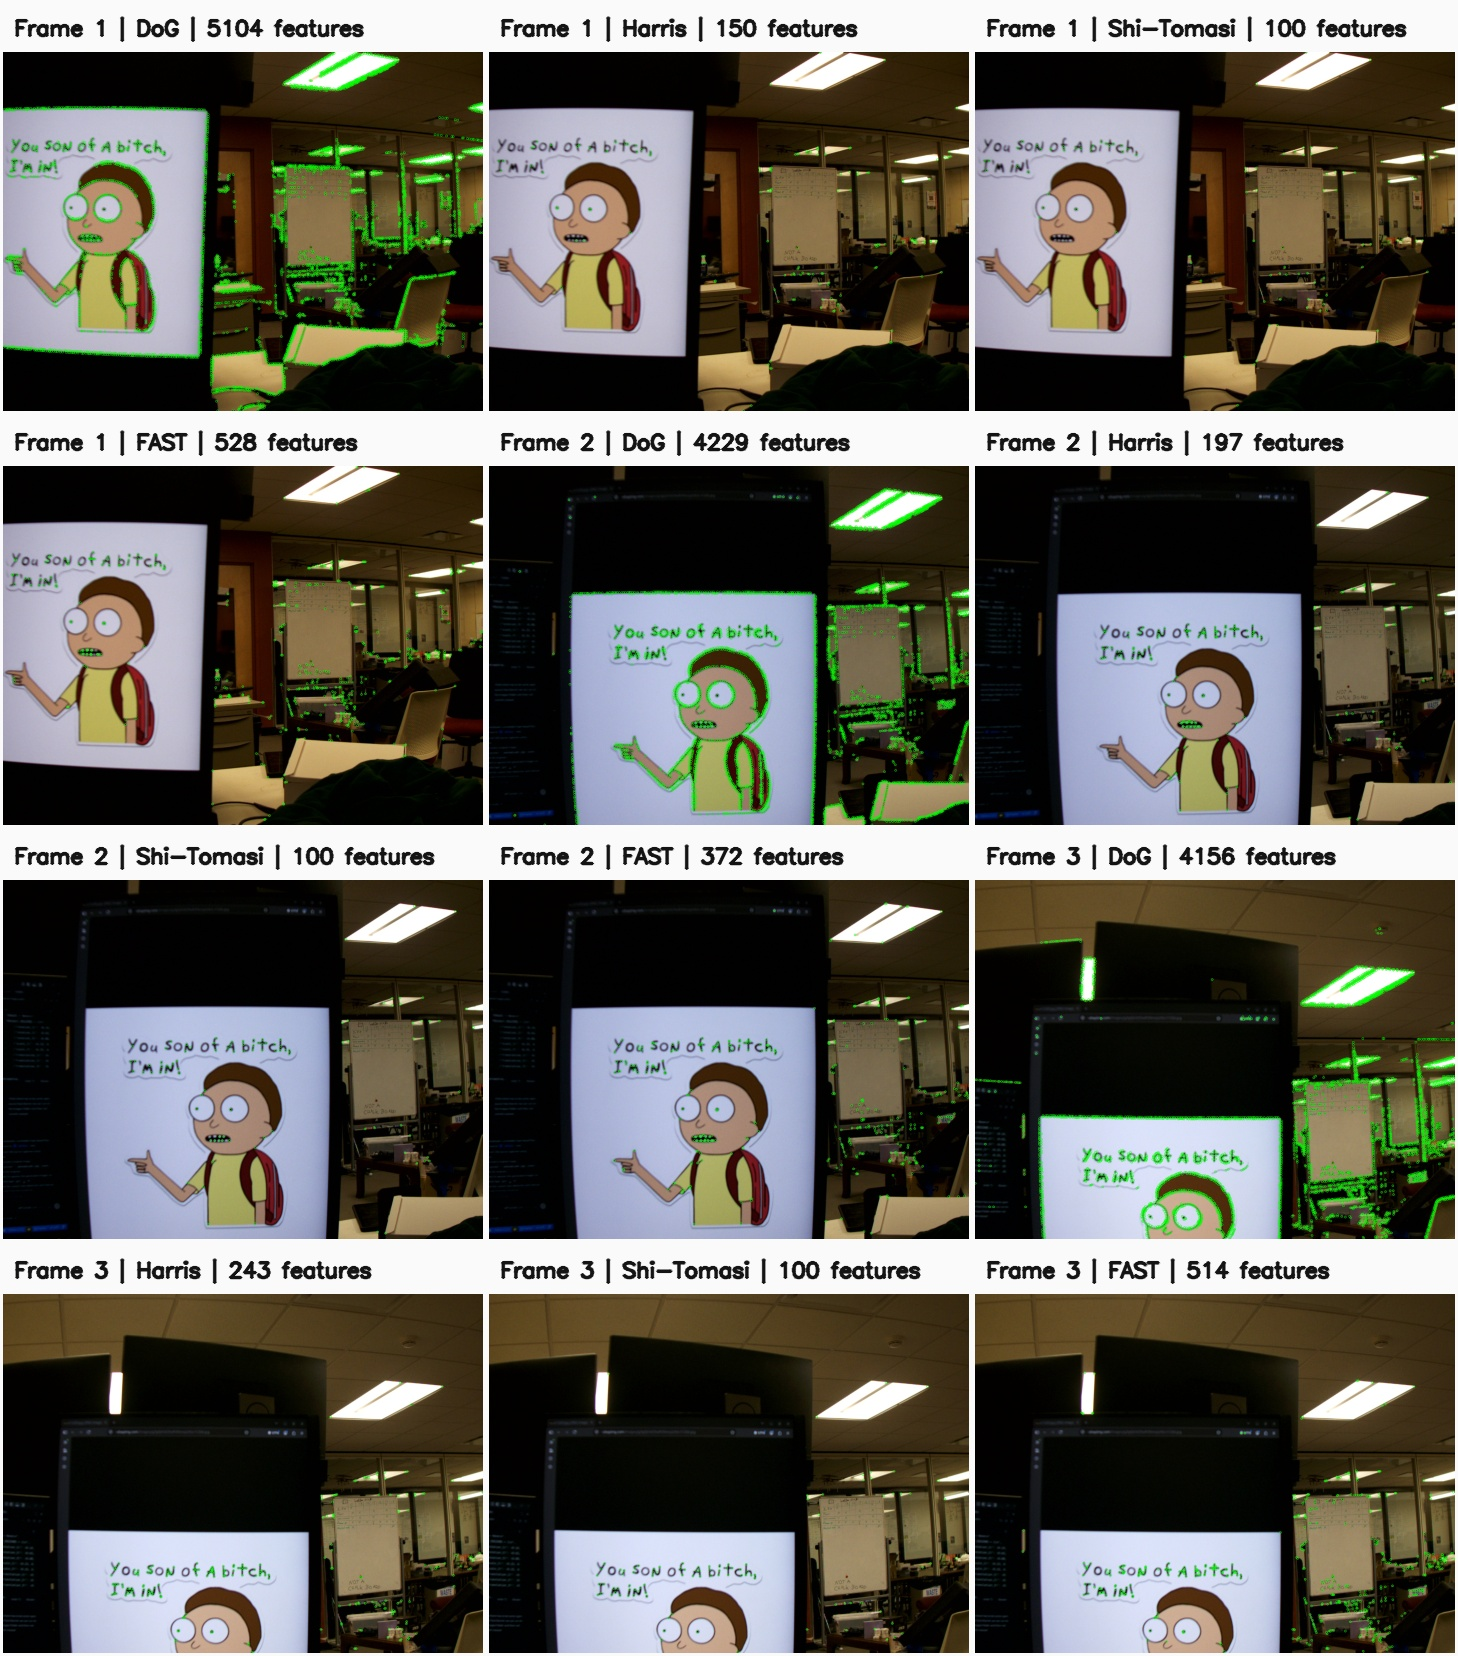

Compare matching physical features across the saved overlays for your scale, translation, and rotation images.
image          detector    time (ms)
-------------  ----------  ---------
rotation_1     DoG         15.71    
rotation_1     Harris      17.63    
rotation_1     Shi-Tomasi  13.77    
rotation_1     FAST        0.35     
rotation_2     DoG         11.35    
rotation_2     Harris      15.93    
rotation_2     Shi-Tomasi  18.01    
rotation_2     FAST        0.44     
rotation_3     DoG         11.18    
rotation_3     Harris      21.45    
rotation_3     Shi-Tomasi  17.45    
rotation_3     FAST        0.37     
scale_1        DoG         12.79    
scale_1        Harris      15.02    
scale_1        Shi-Tomasi  17.7     
scale_1        FAST        0.42     
scale_2        DoG         12.33    
scale_2        Harris      15.38    
scale_2        Shi-Tomasi  17.86    
scale_2        FAST        0.36     
scale_3        DoG         9.88     
scale_3        Harris      15.76    
s

In [3]:
# Question 1 checks
q1_repeatability = check_repeatability()
q1_speed = check_speed()
q1_feature_count = check_number_of_features()


2: Implement a method for selecting a subset of features based on contemporary research. The
method must provide a reasonable set of features covering the whole image. Citations are needed
for this. Octrees and ANMS are candidates for this. I will provide the ANMS paper on
Blackboard.

In [4]:
# Question 2: use the existing FAST and Octree detector classes
Q2_CACHE = None


def _q2_feature_sets():
    """Use the first ImageReader image for the spatial-selection example."""
    global Q2_CACHE
    if Q2_CACHE is None:
        image = load_images()["translation"][1]
        fast = Fast(image)
        octree = Octree(image)
        Q2_CACHE = {
            "fast": fast, "candidates": fast.detect_features(),
            "octree": octree, "selected": octree.detect_features(max_features=500),
        }
    return Q2_CACHE


def show_candidate_features(display_image=True):
    data = _q2_feature_sets()
    if display_image:
        show_output(labeled_panel(draw_features(data["fast"].image, data["candidates"], color=(0, 0, 255)), f"FAST candidates | {len(data['candidates'])} features", 720), "q2_fast_candidates.jpg")
    return data["candidates"]


def show_selected_features(display_image=True):
    data = _q2_feature_sets()
    if display_image:
        show_output(labeled_panel(draw_features(data["octree"].image, data["selected"], color=(0, 255, 255)), f"Octree selected | {len(data['selected'])} features", 720), "q2_octree_selected.jpg")
    return data["selected"]


def check_image_coverage():
    data = _q2_feature_sets()
    rows = [{"method": "FAST candidates", "features": len(data["candidates"])},
            {"method": "Octree-selected", "features": len(data["selected"])}]
    print_table(rows, ("method", "features"))
    print("Citation: Rublee et al., 'ORB: an efficient alternative to SIFT or SURF,' ICCV 2011.")
    return rows


Saved: outputs/q2_feature_selection_comparison.jpg


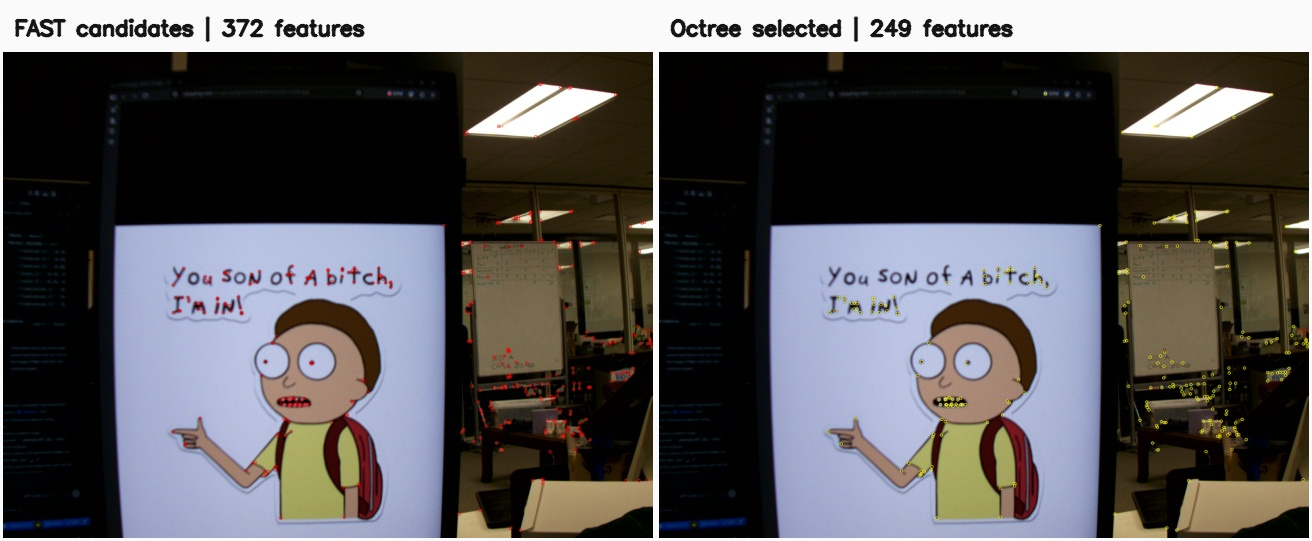

method           features
---------------  --------
FAST candidates  372     
Octree-selected  249     
Citation: Rublee et al., 'ORB: an efficient alternative to SIFT or SURF,' ICCV 2011.


In [5]:
# Question 2 checks
q2_data = _q2_feature_sets()
q2_items = [
    (f"FAST candidates | {len(q2_data['candidates'])} features", draw_features(q2_data["fast"].image, q2_data["candidates"], color=(0, 0, 255))),
    (f"Octree selected | {len(q2_data['selected'])} features", draw_features(q2_data["octree"].image, q2_data["selected"], color=(0, 255, 255))),
]
show_output(image_grid(q2_items, columns=2, panel_width=650), "q2_feature_selection_comparison.jpg")
q2_candidates = q2_data["candidates"]
q2_selected = q2_data["selected"]
q2_coverage = check_image_coverage()


3: Conduct feature matching using SIFT, BRIEF, and ORB feature descriptors. Make sure to pick
one type of detections scheme from above to ensure a good comparison. Look at the speed and
quality of matching. Produce a confusion matrix for each one of these.

In [6]:
# Question 3: use one shared FAST detector with the existing descriptor matchers
MATCHERS = {"SIFT": SIFT, "BRIEF": Brief, "ORB": Orb}
Q3_CACHE = None


def _q3_match_everything():
    """Match the first two ImageReader images with the same FAST keypoints."""
    global Q3_CACHE
    if Q3_CACHE is not None:
        return Q3_CACHE
    images = load_images()["translation"]
    if len(images) < 2:
        raise ValueError("Question 3 needs at least two images in images/.")
    left_image, right_image = images[0], images[-1]
    left_keypoints = Fast(left_image).detect_features()
    right_keypoints = Fast(right_image).detect_features()
    Q3_CACHE = []

    for name, matcher_class in MATCHERS.items():
        matcher = matcher_class(left_image)
        start = perf_counter()
        if name == "SIFT":
            matched_image = matcher.match(right_image, ratio=0.7, keypoints1=left_keypoints, keypoints2=right_keypoints)
        else:
            matched_image = matcher.match(right_image, max_matches=50, keypoints1=left_keypoints, keypoints2=right_keypoints)
        Q3_CACHE.append({
            "descriptor": name, "matched image": matched_image, "matches": len(matcher.matches),
            "time (ms)": round((perf_counter() - start) * 1000, 2),
        })
    return Q3_CACHE


def show_feature_matches():
    items = [(f"{result['descriptor']} | {result['matches']} matches | {result['time (ms)']} ms", result["matched image"])
             for result in _q3_match_everything()]
    show_output(image_grid(items, columns=1, panel_width=1100), "q3_descriptor_matches.jpg")


def check_matching_speed():
    rows = [{"descriptor": item["descriptor"], "time (ms)": item["time (ms)"]}
            for item in _q3_match_everything()]
    print_table(rows, ("descriptor", "time (ms)"))
    return rows


def check_matching_quality():
    rows = [{"descriptor": item["descriptor"], "matches": item["matches"]}
            for item in _q3_match_everything()]
    print_table(rows, ("descriptor", "matches"))
    print("Use the saved overlays to identify correct and incorrect matches.")
    return rows


def build_confusion_matrices(labels):
    """Build matrices after manually labeling match outcomes: (predicted_match, actual_match)."""
    matrices = {}
    for name, outcomes in labels.items():
        matrix = np.zeros((2, 2), dtype=int)  # [[TN, FP], [FN, TP]]
        for predicted, actual in outcomes:
            matrix[int(actual), int(predicted)] += 1
        matrices[name] = matrix
        print(f"{name}: [[TN, FP], [FN, TP]] = {matrix.tolist()}")
    return matrices


Saved: outputs/q3_descriptor_matches.jpg


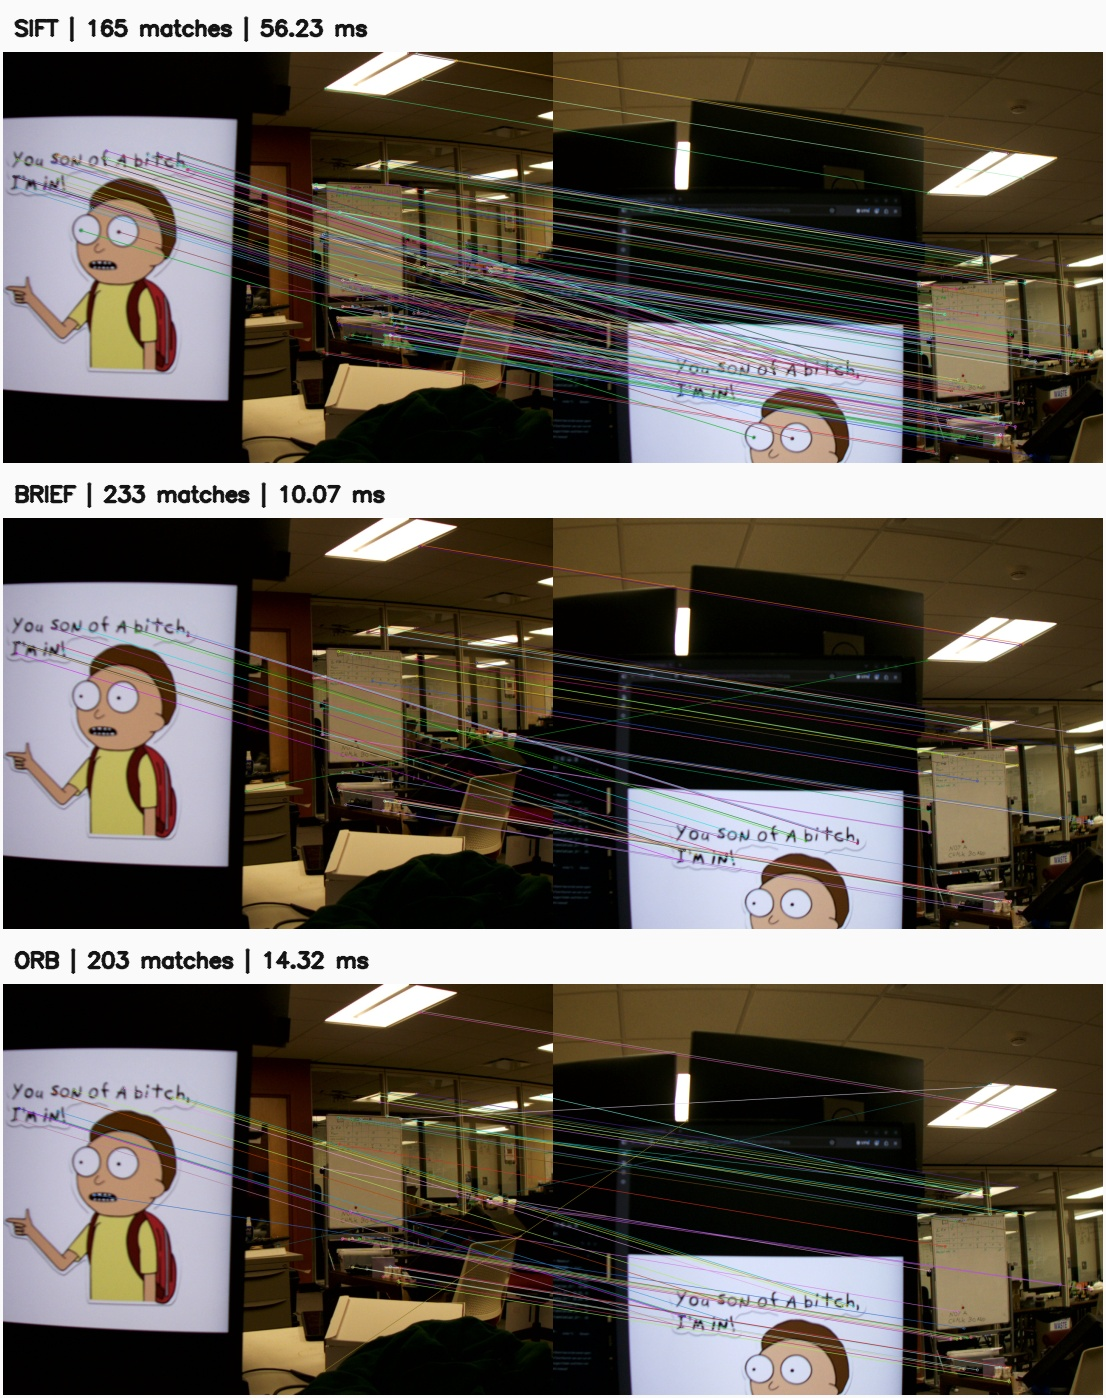

descriptor  time (ms)
----------  ---------
SIFT        56.23    
BRIEF       10.07    
ORB         14.32    
descriptor  matches
----------  -------
SIFT        165    
BRIEF       233    
ORB         203    
Use the saved overlays to identify correct and incorrect matches.


In [7]:
# Question 3 checks
show_feature_matches()
q3_speed = check_matching_speed()
q3_quality = check_matching_quality()

# After manually reviewing match overlays, pass your labels to build_confusion_matrices(...).


## 4: ORB matching ROC curve

ORB is used because it was substantially faster than SIFT in Question 3 while retaining many matches. Match quality is swept using the nearest/second-nearest Hamming-distance ratio; lower ratios are more selective. Geometric consistency under a RANSAC homography supplies the positive/negative labels for this captured planar scene.

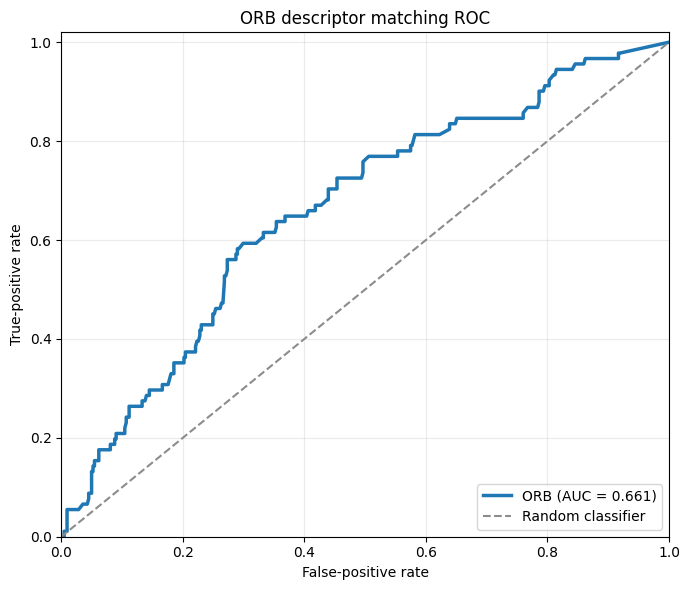

Geometric labels: 91 inliers, 421 outliers
AUC: 0.661
Best ratio threshold by Youden's J: 0.812


In [8]:
# Question 4: ORB ROC curve using FAST detections and geometric verification
import matplotlib.pyplot as plt


def compute_orb_roc(ransac_threshold=5.0):
    left_image, _, right_image = load_images()["translation"]
    left_fast = Fast(left_image).detect_features()
    right_fast = Fast(right_image).detect_features()

    orb = cv2.ORB_create(nfeatures=1000)
    left_keypoints, left_descriptors = orb.compute(cv2.cvtColor(left_image, cv2.COLOR_BGR2GRAY), left_fast)
    right_keypoints, right_descriptors = orb.compute(cv2.cvtColor(right_image, cv2.COLOR_BGR2GRAY), right_fast)
    if left_descriptors is None or right_descriptors is None:
        raise ValueError("ORB could not compute descriptors for the selected images.")

    pairs = cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(left_descriptors, right_descriptors, k=2)
    pairs = [pair for pair in pairs if len(pair) == 2]
    nearest = [pair[0] for pair in pairs]
    ratios = np.array([first.distance / max(second.distance, 1.0) for first, second in pairs])

    source_points = np.float32([left_keypoints[m.queryIdx].pt for m in nearest]).reshape(-1, 1, 2)
    target_points = np.float32([right_keypoints[m.trainIdx].pt for m in nearest]).reshape(-1, 1, 2)
    _, inlier_mask = cv2.findHomography(source_points, target_points, cv2.RANSAC, ransac_threshold)
    if inlier_mask is None:
        raise ValueError("RANSAC could not estimate a homography for the selected images.")
    labels = inlier_mask.ravel().astype(bool)
    positives, negatives = labels.sum(), (~labels).sum()
    if positives == 0 or negatives == 0:
        raise ValueError("ROC analysis requires both geometric inliers and outliers.")

    thresholds = np.r_[-np.inf, np.unique(ratios), np.inf]
    tpr, fpr = [], []
    for threshold in thresholds:
        predicted = ratios <= threshold
        tpr.append(np.count_nonzero(predicted & labels) / positives)
        fpr.append(np.count_nonzero(predicted & ~labels) / negatives)
    tpr, fpr = np.asarray(tpr), np.asarray(fpr)
    auc = np.trapezoid(tpr, fpr)
    youden_index = np.argmax(tpr - fpr)
    return fpr, tpr, auc, thresholds[youden_index], positives, negatives


q4_fpr, q4_tpr, q4_auc, q4_best_ratio, q4_inliers, q4_outliers = compute_orb_roc()
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(q4_fpr, q4_tpr, linewidth=2.5, label=f"ORB (AUC = {q4_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.55", label="Random classifier")
ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title="ORB descriptor matching ROC", xlim=(0, 1), ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
q4_path = OUTPUT_DIR / "q4_orb_roc.png"
fig.savefig(q4_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Geometric labels: {q4_inliers} inliers, {q4_outliers} outliers")
print(f"AUC: {q4_auc:.3f}")
print(f"Best ratio threshold by Youden's J: {q4_best_ratio:.3f}")


### Parameter discussion

The main operating parameter is the nearest/second-nearest Hamming-distance ratio. A lower threshold rejects ambiguous descriptors and reduces false matches, but it can also discard correct matches. A higher threshold improves recall at the cost of more false positives. The data-derived threshold printed above maximizes Youden's $J = \mathrm{TPR}-\mathrm{FPR}$ and is a reasonable balanced setting for these captures. For applications where a false match is especially costly, a stricter threshold should be chosen from the low-FPR portion of the ROC curve.

The FAST threshold controls the number and stability of candidate keypoints; `30` is retained from the earlier comparison. ORB uses `nfeatures=1000` so descriptor computation does not prematurely limit the FAST candidates. The RANSAC reprojection threshold of `5` pixels is used only to form geometric reference labels: decreasing it demands tighter geometric agreement, while increasing it tolerates localization error but risks labeling poor correspondences as inliers.